This notebook is part of the `kikuchipy` documentation https://kikuchipy.org.
Links to the documentation won't work from the notebook.

# High angular resolution orientation similarity maps

Dictionary indexing (<cite data-cite="chen2015dictionary">Chen et al. (2015)</cite>) compares every experimental pattern with patterns simulated for a fixed, uniform sample of orientations, so its angular resolution is limited by the spacing of that sample, typically 1 to 3 degrees.
The orientation similarity map (OSM, <cite data-cite="marquardt2017quantitative">Marquardt et al. (2017)</cite>) counts, for every map point, how many of its best matching dictionary orientations it shares with its nearest neighbours.
It shows grain boundaries, but not orientation differences smaller than the dictionary spacing: two neighbouring points one degree apart usually get the same best matches.

A high angular resolution orientation similarity map (HROSM) resolves such differences by re-indexing every grain against its own fine dictionary.
[hrosm()](../reference/generated/kikuchipy.signals.EBSD.hrosm.rst) of the [EBSD](../reference/generated/kikuchipy.signals.EBSD.rst) signal

1. computes the kernel average misorientation (KAM) of an indexed map,
2. segments the map into grains from the KAM,
3. computes a reference orientation of every grain,
4. simulates a dictionary for every grain from the orientations on a cubochoric grid (<cite data-cite="singh2016orientation">Singh and De Graef (2016)</cite>) within a small angle of the grain's reference orientation, a *misorientation ball*,
5. re-indexes the grain's patterns against that dictionary, and
6. computes the OSM of the re-indexed points.

The method and its defaults come from the program EMHROSM of [EMsoftOO](https://github.com/EMsoft-org/EMsoftOO) by Marc De Graef, which is gratefully acknowledged.
Each step is also available as a function in the [indexing module](../reference/generated/kikuchipy.indexing.rst), which we use below to look at the intermediate results.

In this tutorial, we index a nickel dataset with a dictionary, look at its grains, re-index them and compare the HROSM with the global OSM.
We then show on a synthetic map that HROSM reveals a 0.5 degree sub-grain boundary that a dictionary with a step of 1.4 degrees between its orientations cannot resolve.
We close with advice on the parameters and their cost, and list how this implementation differs from EMHROSM.

In [1]:
# Exchange inline for notebook or qt5 (from pyqt) for interactive plotting
%matplotlib inline

import textwrap
import warnings

import dask
import hyperspy.api as hs
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

import kikuchipy as kp
from orix import plot, sampling
from orix.quaternion import Orientation, Rotation
from orix.vector import Vector3d

plt.rcParams.update({"figure.facecolor": "w", "font.size": 12})

# Silence progressbars
hs.preferences.General.show_progressbar = False


def print_warnings(record):
    """Print the messages of recorded user warnings, wrapped."""
    for w in record:
        if issubclass(w.category, UserWarning):
            print(textwrap.fill(str(w.message), 77))

Pattern simulation and matching run in parallel with Dask's threaded scheduler.
We limit it to eight worker threads; leave this out to use all cores.

In [2]:
_ = dask.config.set(num_workers=8)

## Dictionary indexing and the global orientation similarity map

We index the larger nickel dataset available with kikuchipy, $55 \times 75$ patterns of $60 \times 60$ pixels from recrystallised nickel, as in the [pattern matching tutorial](pattern_matching.ipynb), where every step is explained in more detail.
HROSM re-indexes any indexed map, for example one from [spherical indexing](spherical_indexing.ipynb), as long as its grid matches the patterns; it only needs a master pattern and a detector to simulate the grains' dictionaries.
First, we remove the static and dynamic background.

In [3]:
# Use kp.load("data.h5") to load your own data
s = kp.data.nickel_ebsd_large(allow_download=True)  # External download
s.remove_static_background()
s.remove_dynamic_background()
s

<EBSD, title: patterns Scan 1, dimensions: (75, 55|60, 60)>

We simulate a dictionary from the small nickel master pattern shipped with kikuchipy for orientations sampled with an average spacing of 3 degrees, using the projection center (PC) of the pattern matching tutorial, and only match the pixels inside a circular mask.

In [4]:
energy = 20
mp = kp.data.nickel_ebsd_master_pattern_small(
    projection="lambert", energy=energy
)
ni = mp.phase

R = sampling.get_sample_fundamental(
    method="cubochoric", resolution=3, point_group=ni.point_group
)
det = kp.detectors.EBSDDetector(
    shape=s.axes_manager.signal_shape[::-1],
    pc=[0.4198, 0.2136, 0.5015],
    sample_tilt=70,
)
sim = mp.get_patterns(
    rotations=R,
    detector=det,
    energy=energy,
    dtype_out=np.float32,
    compute=True,
)
signal_mask = ~kp.filters.Window("circular", det.shape).astype(bool)
print(f"Dictionary of {R.size} orientations")

Dictionary of 30443 orientations


We keep the 20 best matches per point, as the OSM needs them, and then refine the best match of every point.

In [5]:
xmap_di = s.dictionary_indexing(
    sim,
    metric="ncc",
    keep_n=20,
    n_per_iteration=sim.axes_manager.navigation_size // 10,
    signal_mask=signal_mask,
)

Dictionary indexing information:
  Phase name: ni
  Matching 4125 experimental pattern(s) to 30443 dictionary pattern(s)
  NormalizedCrossCorrelationMetric: float32, greater is better, rechunk: False, navigation mask: False, signal mask: True


100%|██████████| 11/11 [00:09<00:00,  1.13it/s]


  Indexing speed: 422.80712 patterns/s, 12871517.06311 comparisons/s


In [6]:
xmap = s.refine_orientation(
    xmap=xmap_di,
    detector=det,
    master_pattern=mp,
    energy=energy,
    signal_mask=signal_mask,
    compute=True,
)

Refinement information:
  Method: Nelder-Mead (local) from SciPy
  Trust region (+/-): None
  Keyword arguments passed to method: {'method': 'Nelder-Mead'}
Refining 4125 orientation(s):
[########################################] | 100% Completed | 23.40 s
Refinement speed: 176.22221 patterns/s


The global OSM is computed from the ten best matches of the dictionary indexing, the default of HROSM.
We plot it next to the inverse pole figure (IPF) map of the refined orientations, coloured by the sample X direction, with its colour key in the middle.

Global OSM: median 6.8 of 10


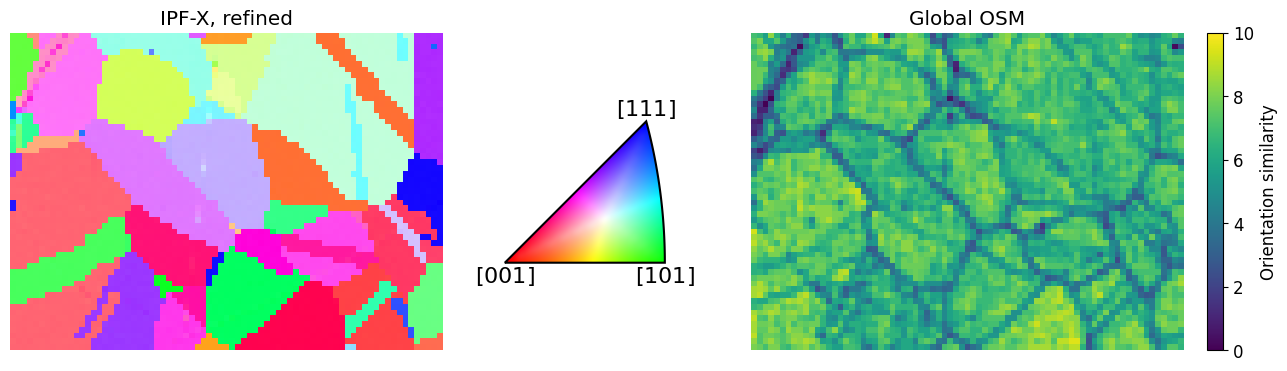

In [7]:
osm_global = kp.indexing.orientation_similarity_map(xmap_di, n_best=10)
print(f"Global OSM: median {np.median(osm_global):.1f} of 10")

ckey = plot.IPFColorKeyTSL(ni.point_group, direction=Vector3d.xvector())
rgb_x = ckey.orientation2color(xmap.orientations).reshape(xmap.shape + (3,))

fig = plt.figure(figsize=(13, 3.6), layout="constrained")
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.35, 1])
ax_ipf = fig.add_subplot(gs[0])
ax_ckey = fig.add_subplot(gs[1], projection="ipf", symmetry=ni.point_group)
ax_osm = fig.add_subplot(gs[2])
ax_ipf.imshow(rgb_x)
ax_ipf.set_title("IPF-X, refined")
ax_ckey.plot_ipf_color_key(show_title=False)
im = ax_osm.imshow(osm_global, vmin=0, vmax=10)
ax_osm.set_title("Global OSM")
fig.colorbar(im, ax=ax_osm, label="Orientation similarity")
for ax in [ax_ipf, ax_osm]:
    ax.axis("off")

The global OSM is high within the grains and drops at the grain boundaries.
Within the grains, its values vary only in steps of whole neighbours sharing a match, so orientation changes smaller than the 3 degree dictionary spacing remain hidden.

## Kernel average misorientation, grains and their reference orientations

The KAM of a point is the mean disorientation angle to its four nearest neighbours (left, right, up and down) that are in the data and of the same phase.
[kernel_average_misorientation_map()](../reference/generated/kikuchipy.indexing.kernel_average_misorientation_map.rst) computes it.
With `emsoft_compatible=True`, it instead reproduces EMHROSM's KAM, which pairs some points with the wrong neighbour (see the last section).

In [8]:
kam = kp.indexing.kernel_average_misorientation_map(xmap)
kam_emsoft = kp.indexing.kernel_average_misorientation_map(
    xmap, emsoft_compatible=True
)
print(f"Median KAM: {np.median(kam):.2f} deg")
print(f"Median KAM, EMsoft compatible: {np.median(kam_emsoft):.2f} deg")

Median KAM: 0.14 deg
Median KAM, EMsoft compatible: 0.15 deg


[segment_grains_kam()](../reference/generated/kikuchipy.indexing.segment_grains_kam.rst) segments the KAM map with EMHROSM's rule.
A point and one of its eight neighbours belong to the same grain if their KAM values differ by at most `threshold` (5 degrees by default).
A grain is a connected set of at least two such points that contains a point with a KAM of at most `threshold`.
All other points, mostly the points along the grain boundaries, where the KAM is large, get the label 0.

In [9]:
grain_id = kp.indexing.segment_grains_kam(kam, threshold=5)
print(
    f"{grain_id.max()} grains; {np.sum(grain_id == 0)} of {grain_id.size} "
    "points are in no grain"
)

47 grains; 1439 of 4125 points are in no grain


[average_grain_orientations()](../reference/generated/kikuchipy.indexing.average_grain_orientations.rst) computes a reference orientation of every grain.
The default `method="mean"` aligns the symmetry variant of every point's orientation with the one of the point nearest the grain's centroid and takes the normalised mean.
The other methods are `"center"`, the orientation of the point nearest the centroid, and `"vmf"` and `"watson"`, the mean of a von Mises-Fisher or Watson distribution fitted by expectation maximisation.
The results are returned in a [GrainTable](../reference/generated/kikuchipy.indexing.GrainTable.rst).

The grain reference orientation deviation (GROD) of a point is its disorientation angle to its grain's reference orientation, computed by [grain_reference_orientation_deviation_map()](../reference/generated/kikuchipy.indexing.grain_reference_orientation_deviation_map.rst).
HROSM can only find orientations within the misorientation ball around the reference orientation, so a warning is raised if the largest GROD of a grain exceeds the ball radius `max_angle`.

In [10]:
with warnings.catch_warnings(record=True) as record:
    warnings.simplefilter("always")
    grains = kp.indexing.average_grain_orientations(
        xmap, grain_id, method="mean", max_angle=5
    )
print_warnings(record)

grod = kp.indexing.grain_reference_orientation_deviation_map(
    xmap, grain_id, grains
)
print(
    f"\n{grains.n_grains} grains, {grains.valid.sum()} with a valid average; "
    f"median GROD {np.nanmedian(grod):.2f} deg"
)

1 grain(s) have a max GROD (grain reference orientation deviation) above the
misorientation ball radius max_angle = 5 deg; the largest max GROD is 5.47
deg. Points beyond the radius can only match orientations on the ball
surface. All of these grains, by descending max GROD: grain 18 (max GROD 5.47
deg, 384 points). Setting max_angle >= 5.5 covers every grain; the cost grows
with the cube of the number of steps across the ball, and keeping the spacing
fixed means increasing n_steps with max_angle.

47 grains, 47 with a valid average; median GROD 0.08 deg


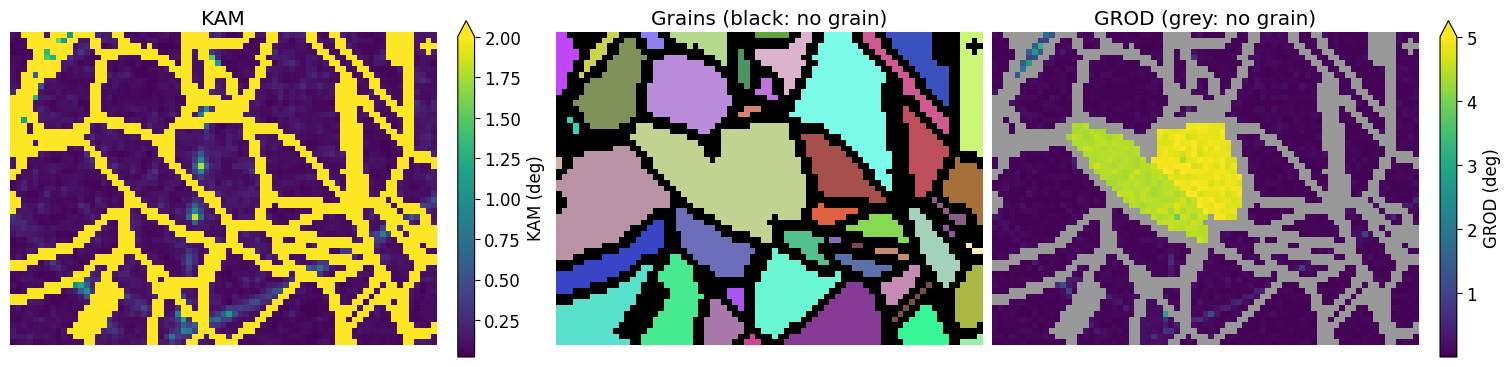

In [11]:
rng = np.random.default_rng(42)
grain_colors = rng.uniform(0.2, 1, (grain_id.max() + 1, 3))
grain_colors[0] = 0
grain_cmap = ListedColormap(grain_colors)

cmap_osm = plt.get_cmap("viridis").with_extremes(bad="0.6")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), layout="constrained")
im0 = axes[0].imshow(kam, vmax=2, cmap=cmap_osm)
fig.colorbar(im0, ax=axes[0], label="KAM (deg)", extend="max")
axes[1].imshow(grain_id, cmap=grain_cmap, interpolation="nearest")
im2 = axes[2].imshow(grod, vmax=5, cmap=cmap_osm)
fig.colorbar(im2, ax=axes[2], label="GROD (deg)", extend="max")
for ax, title in zip(
    axes, ["KAM", "Grains (black: no grain)", "GROD (grey: no grain)"]
):
    ax.set_title(title)
    ax.axis("off")

The KAM is a fraction of a degree within the grains and large across the grain boundaries, which are left out of the grains.
Most grains have a largest GROD of a fraction of a degree, but in the large grain in the centre of the map, every point deviates by more than 4 degrees from the reference orientation.
The IPF map above shows why: this grain consists of two parts (purple and lavender) separated by a low-angle boundary.
The KAM along this boundary is just below 5 degrees, so its points differ by less than `threshold` from their neighbours on either side, and the segmentation keeps both parts in one grain.
Its mean orientation lies between the two parts, and a few points are more than 5 degrees from it.
These can only match orientations on the surface of the ball, which the warning above says, together with the radius that would cover every grain.

A lower `threshold` splits this grain at its low-angle boundary:

In [12]:
largest = int(np.nanargmax(grains.max_grod)) + 1
grain_id2 = kp.indexing.segment_grains_kam(kam, threshold=2)
labels2, counts2 = np.unique(
    grain_id2[grain_id == largest], return_counts=True
)
print(f"Grain {largest} at threshold=2: labels {labels2}, points {counts2}")

grains2 = kp.indexing.average_grain_orientations(xmap, grain_id2)
parts = grains2.rotation[labels2[labels2 > 0] - 1]
ori_parts = Orientation(parts, symmetry=ni.point_group)
angle_parts = ori_parts[0].angle_with(ori_parts[1], degrees=True).item()
print(f"Angle between the two parts: {angle_parts:.1f} deg")
print(
    f"Largest max GROD of all grains: {np.nanmax(grains2.max_grod):.2f} deg"
)

Grain 18 at threshold=2: labels [ 0 18 19], points [ 22 189 173]
Angle between the two parts: 9.3 deg
Largest max GROD of all grains: 3.18 deg


At `threshold=2`, the grain splits into two grains of 189 and 173 points, 9.3 degrees apart, and the largest GROD of all grains drops to 3.2 degrees, well within the ball.
We keep the default threshold here, to see how HROSM handles the merged grain, and return to the parameters at the end.

## Re-indexing the grains

`hrosm()` runs all of the above and re-indexes every grain with at least `min_pixels` points (10 by default).
The misorientation ball has $(2 N + 1)^3$ orientations on a cubochoric grid, with $N$ the number of steps `n_steps` from its centre to its surface, and radius `max_angle`.
[misorientation_ball_spacing()](../reference/generated/kikuchipy.indexing.misorientation_ball_spacing.rst) returns the mean angle between neighbouring orientations of the ball.

In [13]:
for n_steps in [20, 10]:
    spacing = kp.indexing.misorientation_ball_spacing(5, n_steps)
    print(
        f"n_steps={n_steps}: {(2 * n_steps + 1) ** 3} orientations, "
        f"mean spacing {spacing:.3f} deg"
    )

n_steps=20: 68921 orientations, mean spacing 0.159 deg
n_steps=10: 9261 orientations, mean spacing 0.318 deg


The default `n_steps=20` gives 68,921 orientations per grain with a mean spacing of 0.16 degrees, twenty times finer than the dictionary above.
Re-indexing all grains of this map with the defaults takes about three minutes on a 20-core workstation, so here we use `n_steps=10`, with 9,261 orientations and a spacing of 0.32 degrees, which takes about 20 seconds on an otherwise idle 20-core workstation.
We pass the same detector, master pattern and signal mask as for the dictionary indexing.

In [14]:
with warnings.catch_warnings(record=True) as record:
    warnings.simplefilter("always")
    xmap_hrosm = s.hrosm(
        xmap,
        mp,
        det,
        energy=energy,
        max_angle=5,
        n_steps=10,
        signal_mask=signal_mask,
    )
print_warnings(record)

Misorientation ball: 9261 orientations within 5 deg of each grain reference orientation, mean spacing 0.3177 deg; re-indexing 31 grain(s)


Grains: 100%|██████████| 31/31 [00:16<00:00,  1.92it/s]

Re-indexing time: 16.18736 s
1 grain(s) have a max GROD (grain reference orientation deviation) above the
misorientation ball radius max_angle = 5 deg (mean spacing 0.3177 deg); the
largest max GROD is 5.47 deg. Points beyond the radius can only match
orientations on the ball surface. All of these grains, by descending max
GROD: grain 18 (max GROD 5.47 deg, 384 points). Setting max_angle >= 5.5
covers every grain; the cost grows with the cube of the number of steps
across the ball, and keeping the spacing fixed means increasing n_steps with
max_angle.


The returned crystal map holds the best match of every re-indexed point in its grain's ball and the input orientation elsewhere.
Its properties include the OSM (`"osm"`), the `keep_n` best scores (`"scores"`) and the KAM, grain labels and GROD of the input map, as well as `"reindexed"`, which tells which points were re-indexed.

In [15]:
reindexed = xmap_hrosm.prop["reindexed"]
grain_id_hrosm = xmap_hrosm.get_map_data("grain_id")
print(f"Same grains as above: {np.array_equal(grain_id_hrosm, grain_id)}")
print(
    f"Re-indexed: {reindexed.sum()} of {reindexed.size} points in "
    f"{np.unique(xmap_hrosm.prop['grain_id'][reindexed]).size} grains"
)

ncc_refined = xmap.scores[reindexed]
ncc_hrosm = xmap_hrosm.prop["scores"][reindexed, 0]
print(
    f"Median NCC of the re-indexed points: refined {np.median(ncc_refined):.3f}"
    f", HROSM {np.median(ncc_hrosm):.3f}"
)

ori_refined = Orientation(xmap.rotations[reindexed], symmetry=ni.point_group)
ori_hrosm = Orientation(
    xmap_hrosm.rotations[reindexed], symmetry=ni.point_group
)
miso = ori_refined.angle_with(ori_hrosm, degrees=True)
print(f"Median disorientation refined to HROSM: {np.median(miso):.2f} deg")

Same grains as above: True
Re-indexed: 2604 of 4125 points in 31 grains
Median NCC of the re-indexed points: refined 0.504, HROSM 0.503
Median disorientation refined to HROSM: 0.08 deg


The best matches in the balls agree with the refined orientations to within a quarter of the ball spacing, with practically the same scores: the re-indexing finds the refined orientations on a grid ten times finer than the dictionary.
The HROSM next to the global OSM, both with ten matches per point:

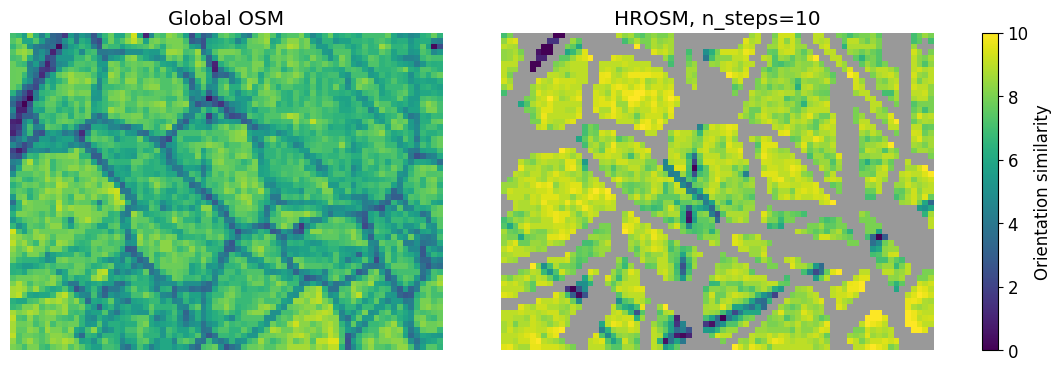

In [16]:
osm_hrosm = xmap_hrosm.get_map_data("osm")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
for ax, osm_i, title in zip(
    axes, [osm_global, osm_hrosm], ["Global OSM", "HROSM, n_steps=10"]
):
    im = ax.imshow(osm_i, vmin=0, vmax=10, cmap=cmap_osm)
    ax.set_title(title)
    ax.axis("off")
_ = fig.colorbar(im, ax=axes, label="Orientation similarity")

In [17]:
osm_global = np.asarray(osm_global)
in_grains = reindexed.reshape(xmap.shape)
sub_boundary = (grain_id == largest) & (grain_id2 == 0)
for name, osm_i in [("Global", osm_global), ("HROSM", osm_hrosm)]:
    print(
        f"{name:6s}: median OSM in the grains {np.nanmedian(osm_i[in_grains]):.1f}"
        f", along the low-angle boundary {np.nanmedian(osm_i[sub_boundary]):.1f}"
    )

Global: median OSM in the grains 7.2, along the low-angle boundary 4.2
HROSM : median OSM in the grains 8.8, along the low-angle boundary 4.5


Points not re-indexed, the grain boundaries and the grains with fewer than ten points, are grey in the HROSM.
Within the grains, the HROSM is higher than the global OSM: on the fine grid of the ball, the best matches of two neighbouring points of the same orientation are neighbours on the grid and largely shared, while the ten best matches in the 3 degree dictionary spread over several degrees and are more easily reordered by noise.
Both maps drop along the 9 degree low-angle boundary in the large grain in the centre (the 22 points left out of the grains at `threshold=2`), but relative to the grain interiors, the drop is larger in the HROSM.

## A sub-grain boundary below the dictionary resolution

To see what HROSM resolves, we simulate a map of $20 \times 30$ points with a sub-grain boundary of known misorientation.
Grain A, the left 15 columns, has the Euler angles (10, 20, 30) degrees, but from column 8 on its orientation is rotated by 0.5 degrees about the crystal [001] axis.
Grain B, the right 15 columns, has the Euler angles (60, 45, 10) degrees.
The patterns of $60 \times 60$ pixels are simulated from the nickel master pattern of both hemispheres at 20 kV, and Gaussian noise with a standard deviation of 2 % of their intensity range is added.

In [18]:
n_rows, n_cols = 20, 30
g_a = Rotation.from_euler(np.deg2rad([10, 20, 30]))
g_b = Rotation.from_euler(np.deg2rad([60, 45, 10]))
g_a2 = Rotation.from_axes_angles([0, 0, 1], np.deg2rad(0.5)) * g_a

cols = np.tile(np.arange(n_cols), n_rows)
truth = np.empty((n_rows * n_cols, 4))
truth[cols < 8] = g_a.data
truth[(cols >= 8) & (cols < 15)] = g_a2.data
truth[cols >= 15] = g_b.data

mp_both = kp.data.nickel_ebsd_master_pattern_small(
    projection="lambert", hemisphere="both"
)
det_syn = kp.detectors.EBSDDetector(
    (60, 60), pc=[0.42, 0.22, 0.50], sample_tilt=70
)
s_syn = mp_both.get_patterns(
    Rotation(truth).reshape(n_rows, n_cols), det_syn, energy=20, compute=True
)
rng = np.random.default_rng(50)
noise_std = 0.02 * float(s_syn.data.max() - s_syn.data.min())
s_syn.data += rng.normal(0, noise_std, s_syn.data.shape).astype(np.float32)

The global dictionary consists of two misorientation balls of radius 10 degrees and $N = 7$ about centres 0.7 degrees away from the two grain orientations, so that no dictionary orientation coincides with the true ones.
Its radial step between shells is $10 / 7 = 1.4$ degrees and its mean spacing 0.9 degrees, both well above the sub-grain misorientation.

In [19]:
rv = Rotation.from_axes_angles([2, -1, 3], np.deg2rad(0.7))
R_syn = Rotation(
    np.concatenate(
        [
            kp.indexing.misorientation_ball(
                rv * g, max_angle=10, n_steps=7
            ).data
            for g in [g_a, g_b]
        ]
    )
)
spacing_syn = kp.indexing.misorientation_ball_spacing(10, 7)
print(
    f"Global dictionary: {R_syn.size} orientations, mean spacing "
    f"{spacing_syn:.2f} deg"
)

sim_syn = mp_both.get_patterns(R_syn, det_syn, energy=20, compute=True)
xmap_syn_di = s_syn.dictionary_indexing(sim_syn, keep_n=10)
osm_syn_global = kp.indexing.orientation_similarity_map(
    xmap_syn_di, n_best=10
)

Global dictionary: 6750 orientations, mean spacing 0.91 deg
Dictionary indexing information:
  Phase name: ni
  Matching 600 experimental pattern(s) to 6750 dictionary pattern(s)
  NormalizedCrossCorrelationMetric: float32, greater is better, rechunk: False, navigation mask: False, signal mask: False
[########################################] | 100% Completed | 103.76 ms
  Indexing speed: 2669.43987 patterns/s, 18018719.09269 comparisons/s


We re-index the map with the default ball, 68,921 orientations within 5 degrees, and keep ten matches per point.

In [20]:
xmap_syn = s_syn.hrosm(
    xmap_syn_di, mp_both, det_syn, energy=20, keep_n=10, verbose=0
)
osm_syn_hrosm = xmap_syn.get_map_data("osm")
print(
    f"Grains: {np.unique(xmap_syn.prop['grain_id'][xmap_syn.prop['reindexed']])}"
)

Grains: [1 2]


The KAM step across the sub-grain boundary is far below the segmentation threshold, so grain A is one grain, and both grains are re-indexed.
We compare the two OSMs, and plot, per map column of grain A (away from the grain boundary to grain B), the median OSM and the median disorientation angle of the found orientation to the one found in the first column of the same row.

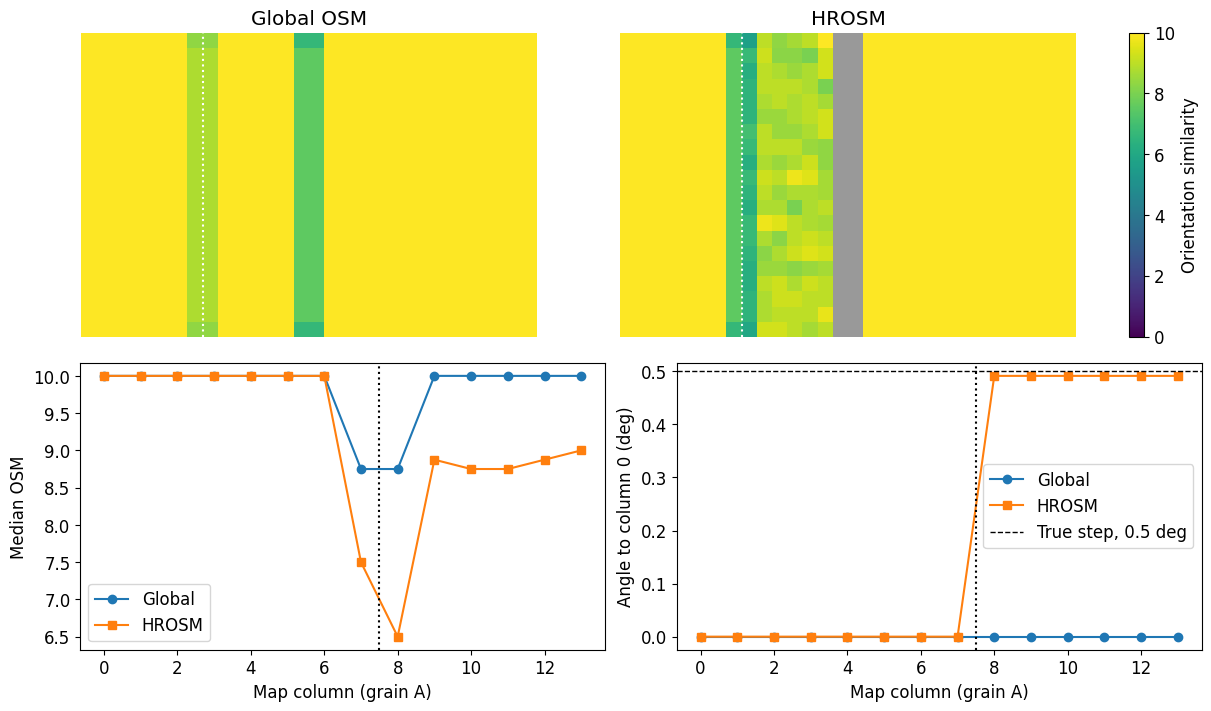

In [21]:
point_group = mp_both.phase.point_group
ori_found = {}
angle_to_first = {}
for name, xmap_i in [("Global", xmap_syn_di), ("HROSM", xmap_syn)]:
    rot = xmap_i.rotations
    if rot.ndim > 1:
        rot = rot[:, 0]
    ori = Orientation(rot, symmetry=point_group).reshape(n_rows, n_cols)
    ori_found[name] = ori
    angle_to_first[name] = np.stack(
        [ori[:, j].angle_with(ori[:, 0], degrees=True) for j in range(14)],
        axis=1,
    )

fig = plt.figure(figsize=(12, 7), layout="constrained")
fig_top, fig_bottom = fig.subfigures(2, 1)
axes = fig_top.subplots(1, 2)
for ax, osm_i, title in zip(
    axes, [osm_syn_global, osm_syn_hrosm], ["Global OSM", "HROSM"]
):
    im = ax.imshow(osm_i, vmin=0, vmax=10, cmap=cmap_osm)
    ax.axvline(7.5, color="w", ls=":")
    ax.set_title(title)
    ax.axis("off")
fig_top.colorbar(im, ax=axes, label="Orientation similarity")

ax_osm, ax_angle = fig_bottom.subplots(1, 2)
for name, osm_i, marker in [
    ("Global", osm_syn_global, "o"),
    ("HROSM", osm_syn_hrosm, "s"),
]:
    ax_osm.plot(
        np.median(osm_i[1:-1, :14], axis=0), marker=marker, label=name
    )
    ax_angle.plot(
        np.median(angle_to_first[name], axis=0), marker=marker, label=name
    )
ax_angle.axhline(0.5, color="k", ls="--", lw=1, label="True step, 0.5 deg")
for ax in [ax_osm, ax_angle]:
    ax.axvline(7.5, color="k", ls=":")
    ax.set_xlabel("Map column (grain A)")
ax_osm.set_ylabel("Median OSM")
ax_angle.set_ylabel("Angle to column 0 (deg)")
ax_osm.legend()
_ = ax_angle.legend()

In [22]:
for name, osm_i in [("Global", osm_syn_global), ("HROSM", osm_syn_hrosm)]:
    ori = ori_found[name]
    step = np.median(ori[:, 9].angle_with(ori[:, 6], degrees=True))
    print(
        f"{name:6s}: step from column 6 to 9 {step:.2f} deg; median OSM in "
        f"columns 7 and 8 {np.median(osm_i[1:-1, 7:9]):.2f}, in columns 1 to 6 "
        f"{np.median(osm_i[1:-1, 1:7]):.2f}, in columns 10 to 13 "
        f"{np.median(osm_i[1:-1, 10:14]):.2f}"
    )

ori_truth = Orientation(Rotation(truth), symmetry=point_group)
ori_hrosm_syn = Orientation(xmap_syn.rotations, symmetry=point_group)
error = ori_truth.angle_with(ori_hrosm_syn, degrees=True)
error = error.reshape(n_rows, n_cols)
print(f"HROSM median error in grain A: {np.median(error[:, :14]):.2f} deg")

Global: step from column 6 to 9 0.00 deg; median OSM in columns 7 and 8 8.75, in columns 1 to 6 10.00, in columns 10 to 13 10.00
HROSM : step from column 6 to 9 0.49 deg; median OSM in columns 7 and 8 7.25, in columns 1 to 6 10.00, in columns 10 to 13 8.75
HROSM median error in grain A: 0.09 deg


The global dictionary finds the same orientation on both sides of the sub-grain boundary.
Its OSM dips in the two columns along the boundary, to 8.75 of 10, where the noise reorders some of the ten best matches, but its orientations do not show the boundary.
HROSM finds the 0.5 degree step, with a median error of less than 0.1 degrees to the true orientations, and its OSM drops further along the boundary, to 7.25, where neighbours across it share fewer matches.
The HROSM is also lower in the right part of grain A (columns 10 to 13, 8.75) than in the left part (columns 1 to 6, 10), since the orientation of the right part lies between the orientations of the ball.
Column 14, along the grain boundary to grain B, is grey in the HROSM: its points are not assigned to a grain and are not re-indexed.

## Choosing the parameters and the cost

* **`max_angle` and `n_steps`.**
  The ball must contain every orientation of a grain, so `max_angle` should be at least the largest GROD of the re-indexed grains; the warning shown above lists the grains beyond it and the radius that covers them all.
  The radial step between the shells of the ball is `max_angle / n_steps`, and the mean spacing returned by `misorientation_ball_spacing()` is about 0.64 times that.
  Keeping the spacing fixed while increasing `max_angle` means increasing `n_steps` in proportion.
* **Cost.**
  The ball has $(2 N + 1)^3$ orientations, so the cost grows with the cube of `n_steps`: 1,331 orientations for $N = 5$, 9,261 for $N = 10$ and 68,921 for $N = 20$.
  Every grain's ball is simulated and matched separately.
  On a 20-core workstation, re-indexing the 31 grains of the nickel map above took 186 seconds at the defaults ($N = 20$, peak memory 1.2 GB) and 22 seconds at $N = 10$ (0.7 GB).
  Most of the time is spent simulating the dictionaries, so the time per grain depends little on the grain's size.
  It is thus worth starting with `n_steps=10`. A smaller `max_angle` that still covers the GROD of the grains gives the same spacing with fewer steps, and the smallest grains can be skipped with a larger `min_pixels`.
* **`threshold` and `dilate`.**
  `threshold` (5 degrees by default) sets the largest KAM difference between neighbours in a grain.
  Low-angle boundaries whose KAM stays below it do not separate grains, as in the nickel map above, where `threshold=2` splits the grain with the largest GROD in two.
  With `dilate=True`, points next to a grain that were left out of it, such as most grain boundary points, join the neighbouring grain with the largest label before averaging and re-indexing.
* **`average`.**
  `"mean"` (the default) is fast and robust for grains with small orientation spreads.
  `"vmf"` and `"watson"` fit a distribution and give a concentration per grain; grains with a concentration below `min_kappa` are then not re-indexed.
  They use `n_em` random initial guesses each, so pass `seed` for reproducible results.
* **`keep_n` and `n_osm`.**
  `keep_n` matches are kept per point, of which the best `n_osm` enter the OSM, so the OSM ranges from 0 to `n_osm`.
* **The detector.**
  A detector with one PC per point is supported: with `pc="grain"` (the default), each grain is simulated with the mean PC of its points, while `pc="single"` uses the average PC of the map for every grain.
* **`n_per_iteration`.**
  By default, as many dictionary patterns are simulated and matched at a time as fit in about 256 MB.
  Lower it if memory is tight.

## Differences from EMsoftOO's EMHROSM

`hrosm()` follows EMHROSM's steps and keyword defaults, and its keyword arguments map to EMHROSM's namelist: `threshold` is `gangle`, `max_angle` is `misorang`, `n_steps` is `nsamples`, `keep_n` is `nnk`, `n_osm` is `nosm`, `average` is `orav`, `n_em` is `numEM`, `n_iter` is `numIter` and `dilate` is `dilate`.
EMHROSM's default reference orientation is the grain centre, `average="center"`.

By default, a number of defects of EMHROSM are corrected.
With `emsoft_compatible=True`, EMHROSM's results are reproduced instead, including these defects:

* The KAM averages the disorientation angles to the existing four nearest neighbours, while EMHROSM credits the pair of a point and the point below it to the point one column to the right of the upper one, compares the last point of the first row with the identity and divides by fixed multipliers per edge and corner.
* Disorientation angles are computed in double precision, while EMHROSM evaluates an unclipped arccosine with its own symmetry operators and operation order.
* Dilation gives an unassigned point the largest label among its neighbours of the same phase, while EMHROSM takes the largest label in every $3 \times 3$ window, which may overwrite labels.
* The `"center"` reference orientation is that of the grain point nearest the centroid, while EMHROSM uses the centre of the bounding box, which may lie outside the grain.
* The `"vmf"` and `"watson"` averages apply the crystal symmetry consistently.
* The ball orientations are kept in double precision, while EMHROSM stores them as single precision Rodrigues vectors.
* Only a grain's own points are matched against its ball, while EMHROSM matches its whole bounding box.
* The OSM of a point is the mean over its neighbours in the same grain that were re-indexed, while EMHROSM uses its KAM neighbour bookkeeping.
* Points not in the data, several phases and one PC per point are supported, and points not re-indexed keep their input orientation, while EMHROSM sets the identity and a score and similarity of zero.

The KAM shows the first difference.
The two KAM maps of the nickel map computed above differ slightly at most points, and by several degrees at points next to the grain boundaries, where EMHROSM credits a large boundary angle to the wrong point, and at the last point of the first row, which is compared with the identity.

Median |difference|: 1.8e-02 deg
Points differing by more than 0.1 deg: 842
Last point of the first row: 0.14 deg, EMsoft compatible 18.05 deg


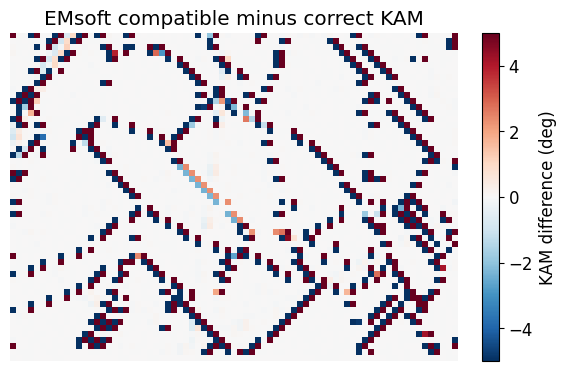

In [23]:
kam_diff = kam_emsoft - kam
print(f"Median |difference|: {np.median(np.abs(kam_diff)):.1e} deg")
print(
    f"Points differing by more than 0.1 deg: {np.sum(np.abs(kam_diff) > 0.1)}"
)
print(
    f"Last point of the first row: {kam[0, -1]:.2f} deg, "
    f"EMsoft compatible {kam_emsoft[0, -1]:.2f} deg"
)

fig, ax = plt.subplots(figsize=(6, 3.6), layout="constrained")
im = ax.imshow(kam_diff, cmap="RdBu_r", vmin=-5, vmax=5)
fig.colorbar(im, ax=ax, label="KAM difference (deg)")
ax.set_title("EMsoft compatible minus correct KAM")
_ = ax.axis("off")

Since grains are segmented from the KAM, the two modes can give different grains, and so different HROSMs, on the same map.
The `emsoft_compatible=True` mode is meant for comparisons with EMHROSM results; the default mode is recommended otherwise.